In [21]:
import os
import random
from pathlib import Path
import yaml
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [22]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset_yolo"
DATA_YAML = DATASET_DIR / "data.yaml"

IMAGES_TRAIN = DATASET_DIR / "images" / "train"
IMAGES_VAL = DATASET_DIR / "images" / "val"
LABELS_TRAIN = DATASET_DIR / "labels" / "train"
LABELS_VAL = DATASET_DIR / "labels" / "val"

print("Project root:", PROJECT_ROOT)
print("Dataset dir :", DATASET_DIR)
print("data.yaml   :", DATA_YAML)

Project root: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project
Dataset dir : C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo
data.yaml   : C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\data.yaml


In [23]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset_yolo"
DATA_YAML = DATASET_DIR / "data.yaml"

IMAGES_TRAIN = DATASET_DIR / "images" / "train"
IMAGES_VAL = DATASET_DIR / "images" / "val"
LABELS_TRAIN = DATASET_DIR / "labels" / "train"
LABELS_VAL = DATASET_DIR / "labels" / "val"

required_paths = {
    "DATASET_DIR": DATASET_DIR,
    "DATA_YAML": DATA_YAML,
    "IMAGES_TRAIN": IMAGES_TRAIN,
    "IMAGES_VAL": IMAGES_VAL,
    "LABELS_TRAIN": LABELS_TRAIN,
    "LABELS_VAL": LABELS_VAL,
}

print("Current working directory:", PROJECT_ROOT)
print()

missing = []
for name, path in required_paths.items():
    exists = path.exists()
    print(f"{name}: {path} -> {'OK' if exists else 'MISSING'}")
    if not exists:
        missing.append((name, path))

if missing:
    raise FileNotFoundError("Some required training paths are missing. See list above.")

Current working directory: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project

DATASET_DIR: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo -> OK
DATA_YAML: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\data.yaml -> OK
IMAGES_TRAIN: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\train -> OK
IMAGES_VAL: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val -> OK
LABELS_TRAIN: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\labels\train -> OK
LABELS_VAL: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\labels\val -> OK


In [24]:
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

print("data.yaml contents:")
print(data_config)

data.yaml contents:
{'path': 'dataset_yolo', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'licence'}}


In [25]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_images = [p for p in IMAGES_TRAIN.iterdir() if p.suffix.lower() in IMAGE_EXTS]
val_images = [p for p in IMAGES_VAL.iterdir() if p.suffix.lower() in IMAGE_EXTS]
train_labels = list(LABELS_TRAIN.glob("*.txt"))
val_labels = list(LABELS_VAL.glob("*.txt"))

print(f"Train images: {len(train_images)}")
print(f"Val images  : {len(val_images)}")
print(f"Train labels: {len(train_labels)}")
print(f"Val labels  : {len(val_labels)}")

Train images: 303
Val images  : 65
Train labels: 303
Val labels  : 65


In [26]:
def find_missing_labels(image_files, label_dir):
    missing = []
    for img_path in image_files:
        label_path = label_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            missing.append(img_path.name)
    return missing

missing_train = find_missing_labels(train_images, LABELS_TRAIN)
missing_val = find_missing_labels(val_images, LABELS_VAL)

print("Missing train labels:", len(missing_train))
if missing_train[:10]:
    print(missing_train[:10])

print("Missing val labels:", len(missing_val))
if missing_val[:10]:
    print(missing_val[:10])

if missing_train or missing_val:
    raise ValueError("Some images do not have matching label files.")
else:
    print("Every image has a matching label file.")

Missing train labels: 0
Missing val labels: 0
Every image has a matching label file.


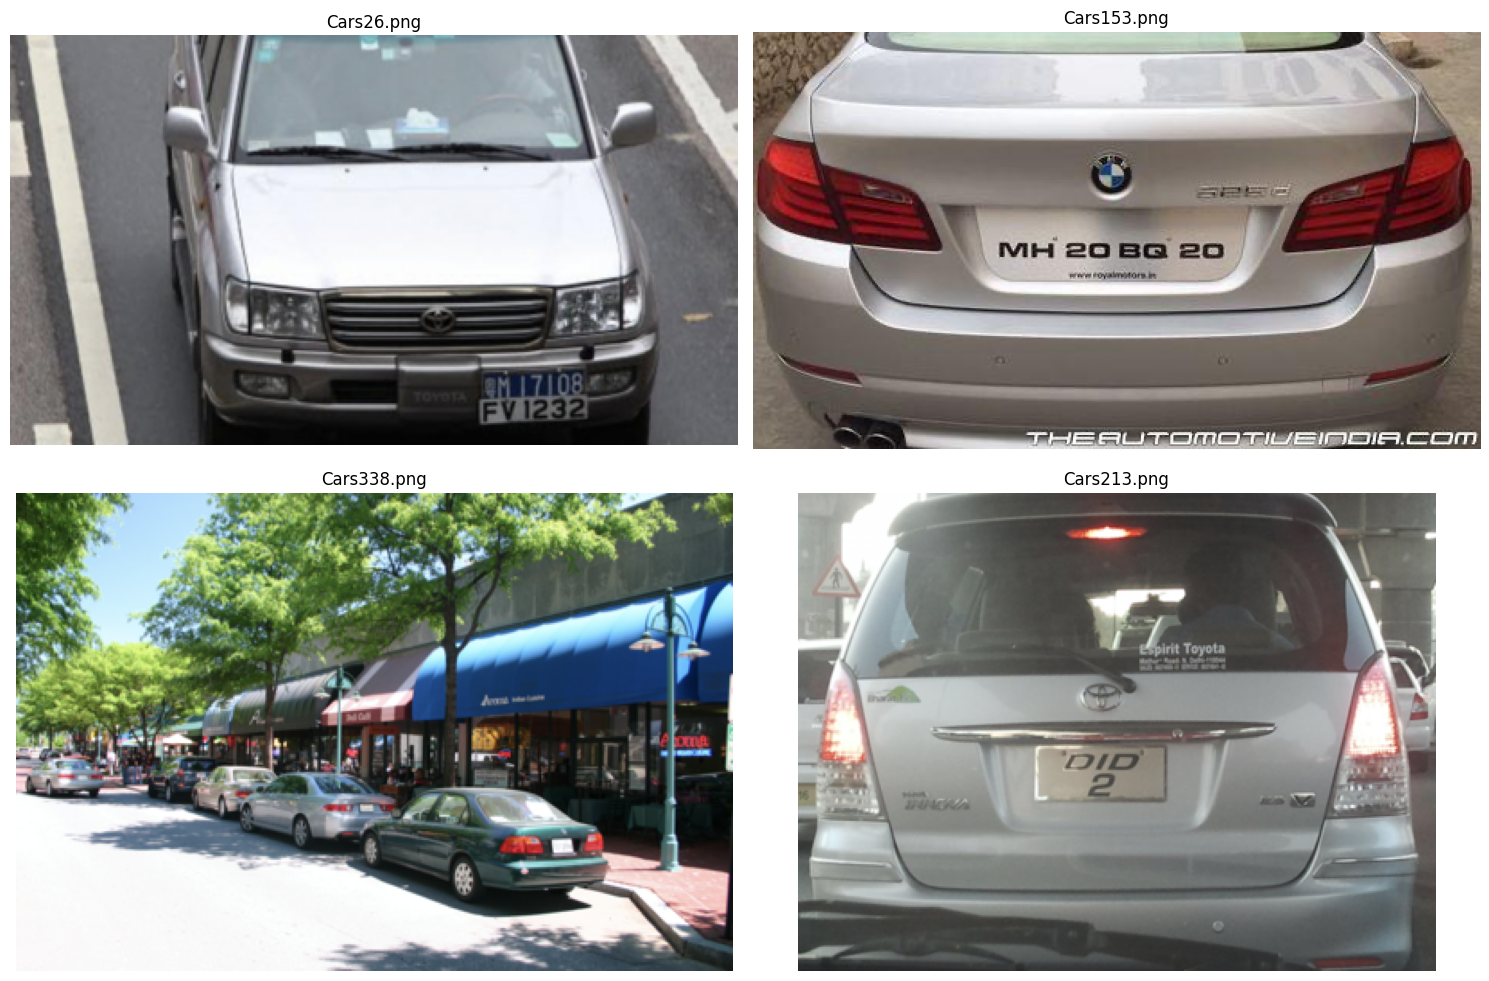

In [27]:
def show_random_images(image_list, n=4):
    sample = random.sample(image_list, min(n, len(image_list)))
    plt.figure(figsize=(15, 10))
    
    for i, img_path in enumerate(sample, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 2, i)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_random_images(train_images, n=4)

In [ ]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=8,
    project="runs",
    name="plate_detector",
    exist_ok=True
)

Ultralytics 8.4.30  Python-3.11.7 torch-2.11.0+cpu CPU (13th Gen Intel Core i7-13620H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detector, nbs=64, nms=False, opset=None,

In [ ]:
best_model_path = PROJECT_ROOT / "runs" / "plate_detector" / "weights" / "best.pt"
print("Best model path:", best_model_path)

if not best_model_path.exists():
    raise FileNotFoundError("best.pt not found. Training may have failed or saved elsewhere.")

best_model = YOLO(str(best_model_path))
print("Best model loaded successfully.")

In [ ]:
metrics = best_model.val(data=str(DATA_YAML))
metrics

In [ ]:
pred_results = best_model.predict(
    source=str(IMAGES_VAL),
    save=True,
    conf=0.25,
    project="runs",
    name="plate_detector_predictions",
    exist_ok=True
)

In [ ]:
pred_dir = PROJECT_ROOT / "runs" / "plate_detector_predictions"
print("Predictions saved in:", pred_dir)

In [ ]:
predicted_images = [p for p in pred_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]

if not predicted_images:
    print("No predicted images found.")
else:
    plt.figure(figsize=(15, 10))
    sample = random.sample(predicted_images, min(4, len(predicted_images)))
    
    for i, img_path in enumerate(sample, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 2, i)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
print("Training complete.")
print("Best model:", best_model_path)
print("Prediction outputs:", pred_dir)